In [20]:
import numpy as np
from scipy.stats import norm


class GaussianMixture1D:
    def __init__(self, weights, means, stds):
        self.weights = np.asarray(weights, dtype=float)
        self.means = np.asarray(means, dtype=float)
        self.stds = np.asarray(stds, dtype=float)

        if not (len(self.weights) == len(self.means) == len(self.stds)):
            raise ValueError("weights, means, and stds must have the same length")

        if np.any(self.stds <= 0):
            raise ValueError("All standard deviations must be positive")

        if np.any(self.weights < 0):
            raise ValueError("All weights must be non-negative")

        weight_sum = self.weights.sum()
        if not np.isclose(weight_sum, 1.0):
            self.weights = self.weights / weight_sum  # normalize automatically

    def pdf(self, x):
        """
        Probability density function of the Gaussian mixture.
        x can be a scalar or a NumPy array.
        """
        x = np.asarray(x, dtype=float)

        # Shape: (n_points, n_components)
        component_pdfs = norm.pdf(
            x[..., np.newaxis],
            loc=self.means,
            scale=self.stds
        )

        return np.sum(self.weights * component_pdfs, axis=-1)

    def cdf(self, x):
        """
        Cumulative distribution function of the Gaussian mixture.
        x can be a scalar or a NumPy array.
        """
        x = np.asarray(x, dtype=float)

        # Shape: (n_points, n_components)
        component_cdfs = norm.cdf(
            x[..., np.newaxis],
            loc=self.means,
            scale=self.stds
        )

        return np.sum(self.weights * component_cdfs, axis=-1)

PDF at x=0: 0.031536126683237055
CDF at x=0: 0.40868238898362136


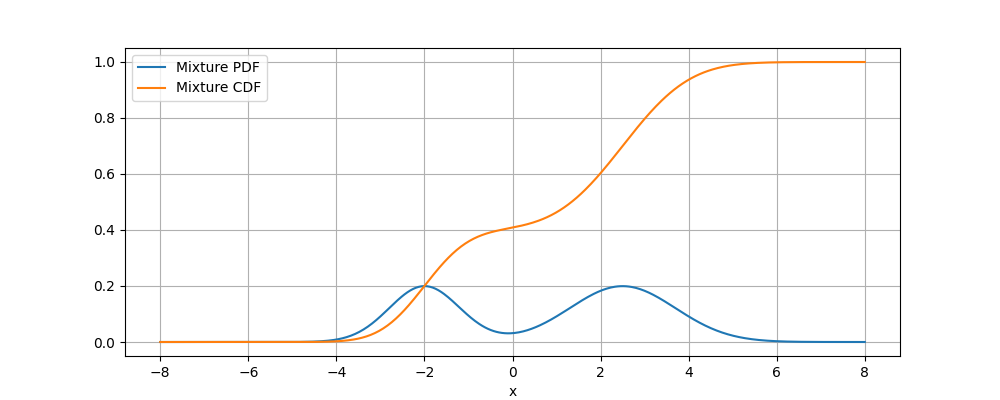

In [21]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib widget

# Example: bimodal Gaussian mixture
weights = [0.4, 0.6]
means = [-2.0, 2.5]
stds = [0.8, 1.2]

gmm = GaussianMixture1D(weights, means, stds)

x = np.linspace(-8, 8, 500)
pdf_vals = gmm.pdf(x)
cdf_vals = gmm.cdf(x)

print("PDF at x=0:", gmm.pdf(0.0))
print("CDF at x=0:", gmm.cdf(0.0))

plt.figure(figsize=(10, 4))
plt.plot(x, pdf_vals, label="Mixture PDF")
plt.plot(x, cdf_vals, label="Mixture CDF")
plt.legend()
plt.xlabel("x")
plt.grid(True)
plt.show()

In [22]:
import numpy as np
from scipy.stats import norm

def gaussian_mixture_pdf(x, weights, means, stds):
    x = np.asarray(x, dtype=float)
    weights = np.asarray(weights, dtype=float)
    means = np.asarray(means, dtype=float)
    stds = np.asarray(stds, dtype=float)

    weights = weights / weights.sum()
    return np.sum(
        weights * norm.pdf(x[..., None], loc=means, scale=stds),
        axis=-1
    )

def gaussian_mixture_cdf(x, weights, means, stds):
    x = np.asarray(x, dtype=float)
    weights = np.asarray(weights, dtype=float)
    means = np.asarray(means, dtype=float)
    stds = np.asarray(stds, dtype=float)

    weights = weights / weights.sum()
    return np.sum(
        weights * norm.cdf(x[..., None], loc=means, scale=stds),
        axis=-1
    )



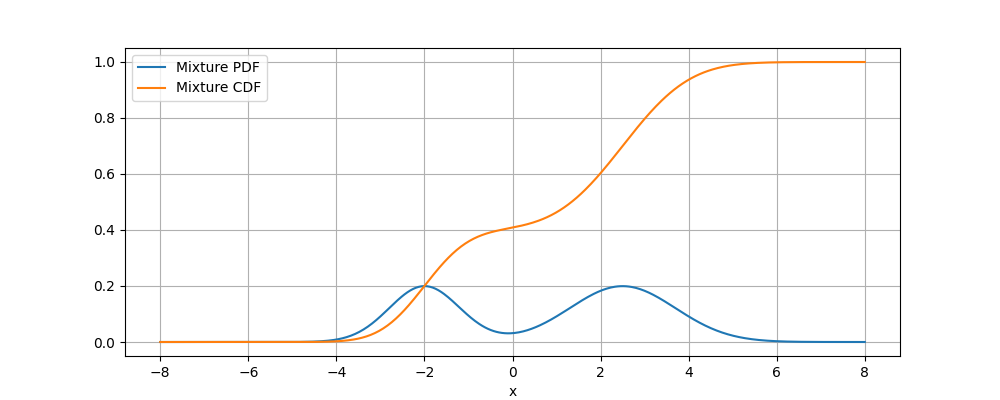

In [23]:
# Example: bimodal Gaussian mixture
weights = [0.4, 0.6]
means = [-2.0, 2.5]
stds = [0.8, 1.2]

x = np.linspace(-8, 8, 500)

pdf_vals2 = gaussian_mixture_pdf(x, weights, means, stds)
cdf_vals2 = gaussian_mixture_cdf(x, weights, means, stds)
cdf_vals3 = gaussian_mixture_ppf(x, weights, means, stds)

plt.figure(figsize=(10, 4))
plt.plot(x, pdf_vals2, label="Mixture PDF")
plt.plot(x, cdf_vals2, label="Mixture CDF")
plt.legend()
plt.xlabel("x")
plt.grid(True)
plt.show()


In [32]:
import numpy as np
from scipy.stats import norm
from scipy.optimize import root_scalar


class GaussianMixture1D:
    def __init__(self, weights, means, sigmas):
        self.weights = np.asarray(weights, dtype=float)
        self.means = np.asarray(means, dtype=float)
        self.sigmas = np.asarray(sigmas, dtype=float)

        if not (len(self.weights) == len(self.means) == len(self.sigmas)):
            raise ValueError("weights, means, and sigmas must have the same length")

        if np.any(self.sigmas <= 0):
            raise ValueError("All sigmas must be strictly positive")

        if np.any(self.weights < 0):
            raise ValueError("All weights must be nonnegative")

        s = self.weights.sum()
        if s <= 0:
            raise ValueError("At least one weight must be positive")
        self.weights = self.weights / s

        self._prepare_interpolator()

    def cdf(self, x):
        """
        Mixture CDF at scalar or array x.
        """
        x = np.asarray(x, dtype=float)
        z = (x[..., None] - self.means) / self.sigmas
        return np.sum(self.weights * norm.cdf(z), axis=-1)

    def pdf(self, x):
        """
        Mixture PDF at scalar or array x.
        """
        x = np.asarray(x, dtype=float)
        z = (x[..., None] - self.means) / self.sigmas
        return np.sum(self.weights * norm.pdf(z) / self.sigmas, axis=-1)

    def _default_bracket(self, tail_sigma=12.0):
        """
        Build a wide bracket [lo, hi] that should contain almost all mass.
        """
        lo = np.min(self.means - tail_sigma * self.sigmas)
        hi = np.max(self.means + tail_sigma * self.sigmas)
        return lo, hi

    def ppf(self, q, bracket=None, method="brentq"):
        """
        Quantile function for scalar or array q in [0, 1].

        Uses numerical root-finding on cdf(x) - q = 0.
        """
        q = np.asarray(q, dtype=float)

        if np.any((q < 0) | (q > 1)):
            raise ValueError("All q values must be in [0, 1]")

        # Handle edge cases exactly
        out = np.empty_like(q, dtype=float)
        out[q == 0] = -np.inf
        out[q == 1] = np.inf

        mask = (q > 0) & (q < 1)
        if not np.any(mask):
            return out.item() if out.ndim == 0 else out

        lo, hi = bracket if bracket is not None else self._default_bracket()

        # Expand bracket if needed to guarantee sign change
        # We need cdf(lo) <= q <= cdf(hi) for all q in mask
        active_q = q[mask]
        cdf_lo = self.cdf(lo)
        cdf_hi = self.cdf(hi)

        expand_count = 0
        while (cdf_lo > np.min(active_q) or cdf_hi < np.max(active_q)) and expand_count < 20:
            width = hi - lo
            lo -= width
            hi += width
            cdf_lo = self.cdf(lo)
            cdf_hi = self.cdf(hi)
            expand_count += 1

        if cdf_lo > np.min(active_q) or cdf_hi < np.max(active_q):
            raise RuntimeError("Could not find a valid root bracket")

        # Solve each quantile independently
        flat_out = out.reshape(-1)
        flat_q = q.reshape(-1)

        for i, qi in enumerate(flat_q):
            if qi == 0:
                flat_out[i] = -np.inf
            elif qi == 1:
                flat_out[i] = np.inf
            else:
                result = root_scalar(
                    lambda x: self.cdf(x) - qi,
                    bracket=[lo, hi],
                    method=method
                )
                if not result.converged:
                    raise RuntimeError(f"Root finder failed for q={qi}")
                flat_out[i] = result.root

        return out.item() if out.ndim == 0 else out

    def _prepare_interpolator(self, grid_size=20000):
        lo, hi = self._default_bracket()
        self.x_grid = np.linspace(lo, hi, grid_size)
        cdf_grid = self.cdf(self.x_grid)
        # Force numerical monotonicity
        self.cdf_grid = np.maximum.accumulate(cdf_grid)

    def ppf_interpolated(self, value):
        if np.any((value < 0) | (value > 1)):
            return -np.inf
        return np.interp(value, self.cdf_grid, self.x_grid)

    def ppf_interpolated_array(self, value):
        value = np.asarray(value, dtype=float)
        out = np.empty_like(value, dtype=float)
        out[value == 0] = -np.inf
        out[value == 1] = np.inf

        mask = (value > 0) & (value < 1)
        out[mask] = np.interp(value[mask], self.cdf_grid, self.x_grid)

        return out.item() if out.ndim == 0 else out

        

In [33]:
gm = GaussianMixture1D(
    weights=[0.3, 0.7],
    means=[-2.0, 3.0],
    sigmas=[0.8, 1.2]
)

qs = np.array([0.01, 0.10, 0.25, 0.50, 0.75, 0.90, 0.99])
xs = gm.ppf(qs)

print("q    =", qs)
print("ppf  =", xs)
print("cdf(ppf(q)) =", gm.cdf(xs))

q    = [0.01 0.1  0.25 0.5  0.75 0.9  0.99]
ppf  = [-3.4671326  -2.34460349 -1.22765487  2.32086146  3.43932763  4.28108463
  5.62721971]
cdf(ppf(q)) = [0.01 0.1  0.25 0.5  0.75 0.9  0.99]


In [50]:
x1 = np.linspace(0.000001, 1.0, 10000)


In [51]:
from time import time

time_01 = time()
dist01 = gm.ppf(x1)
elapsed_time = time() - time_01
print(elapsed_time)

time_01 = time()
dist02 = gm.ppf_interpolated_array(x1)
elapsed_time = time() - time_01
print(elapsed_time)

x_init = np.arange(-5, 5, 0.2)
pdf_vals2 = gm.pdf(x_init)


9.24963927268982
0.0009114742279052734


/tmp/ipykernel_909/3443299674.py:1: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(10, 4))


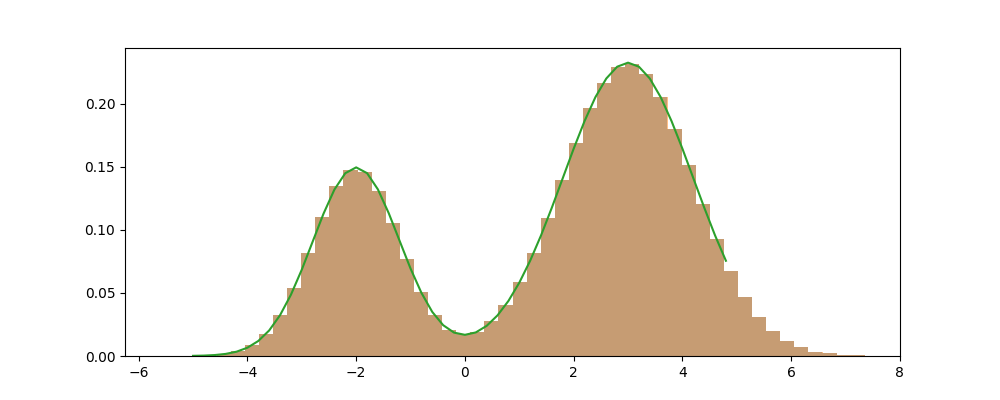

In [53]:
plt.figure(figsize=(10, 4))
sel01 = np.isfinite(dist01)
sel02 = np.isfinite(dist02)

plt.hist(dist01[sel01], bins=50, density=True, alpha=0.5)
plt.hist(dist02[sel02], bins=50, density=True, alpha=0.5)
plt.plot(x_init, pdf_vals2, label="Mixture PDF")

plt.show()

In [61]:
def get_coeff():
    bounds = [-6, 8]

    x_var = np.linspace(0.000000, 1.000000, num=10001, endpoint=True, dtype=np.double)*(bounds[1]-bounds[0]) + bounds[0]
    area = np.zeros(len(x_var), dtype=np.double)

    for x_num, x_val in enumerate(x_var):
        #area[x_num:] += np.exp( giveback_prior_in_log) * (1. / 10000.) + 0.000000000001
        area[x_num:] += gm.pdf(x_val) * (1. / 10000.) + 0.000000000001
    area[0] = 0
    area /= area[-1]

    return splrep(area, x_var)

In [67]:
from scipy.interpolate import splrep, splev

coeff = get_coeff()

time_01 = time()
dist03 = splev(x1, coeff)
elapsed_time = time() - time_01
print(elapsed_time)

0.0013451576232910156


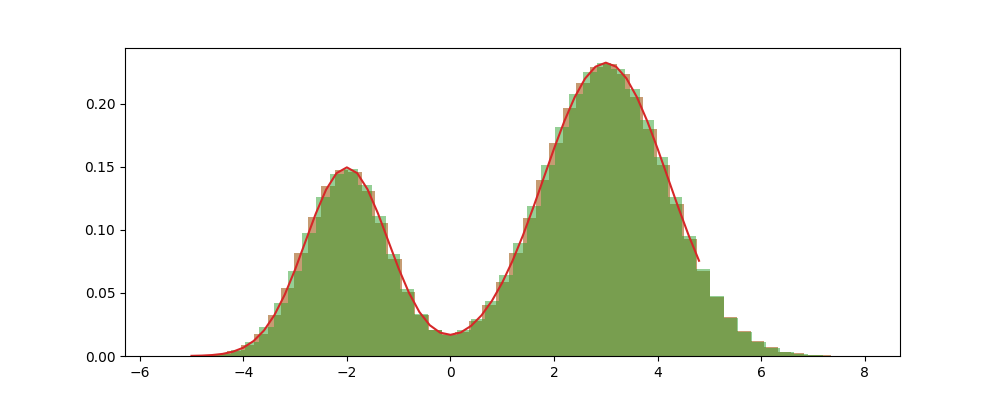

In [66]:
plt.figure(figsize=(10, 4))
sel01 = np.isfinite(dist01)
sel02 = np.isfinite(dist02)
sel03 = np.isfinite(dist03)

plt.hist(dist01[sel01], bins=50, density=True, alpha=0.5)
plt.hist(dist02[sel02], bins=50, density=True, alpha=0.5)
plt.hist(dist03[sel03], bins=50, density=True, alpha=0.5)
plt.plot(x_init, pdf_vals2, label="Mixture PDF")

plt.show()

In [74]:
x2 = np.linspace(0.000001, 1.0, 1000000)
time_01 = time()
dist02_extended = gm.ppf_interpolated_array(x2)
elapsed_time = time() - time_01
print(elapsed_time)

time_01 = time()
dist03_extended = splev(x2, coeff)
elapsed_time = time() - time_01
print(elapsed_time)

0.035004377365112305
0.1063849925994873


65


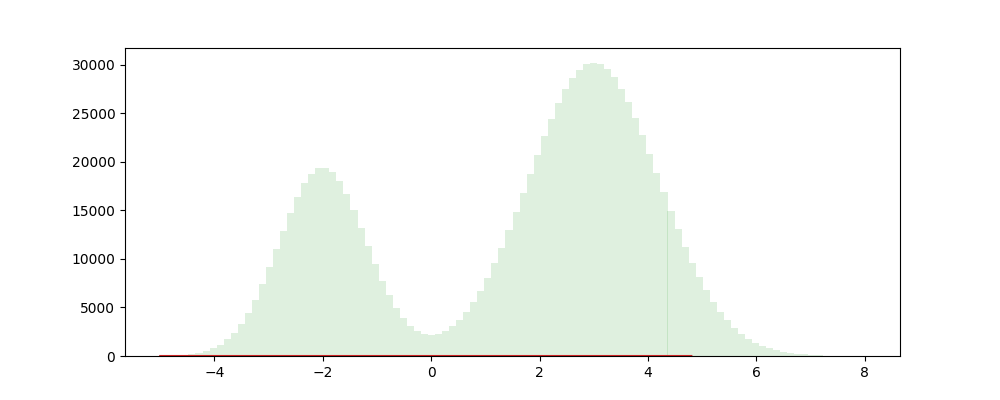

In [88]:
bins = np.arange(-5.,8., 0.2)
print(len(bins))
plt.figure(figsize=(10, 4))
sel01 = np.isfinite(dist01)
sel02 = np.isfinite(dist02_extended)
sel03 = np.isfinite(dist03_extended)

plt.hist(dist01[sel01], bins=100,  range=[-5.,8.], density=True, alpha=0.15)
plt.hist(dist02_extended[sel02], bins=100, range=[-5.,8.], density=True, alpha=0.15)
plt.hist(dist03_extended[sel03], bins=100,  range=[-5.,8.], alpha=0.15)
plt.plot(x_init, pdf_vals2, label="Mixture PDF")

plt.show()


In [99]:
def double_pdf(inc, sigma, xval):
        delta_inc = np.abs(90. - inc)
        xval = np.asarray(xval, dtype=float)
        z = (xval[..., None] - [90. - delta_inc, 90.+ delta_inc]) / [sigma, sigma]
        return np.sum([0.5, 0.5] * norm.pdf(z) / [sigma, sigma], axis=-1)

2.723301982664613e-05


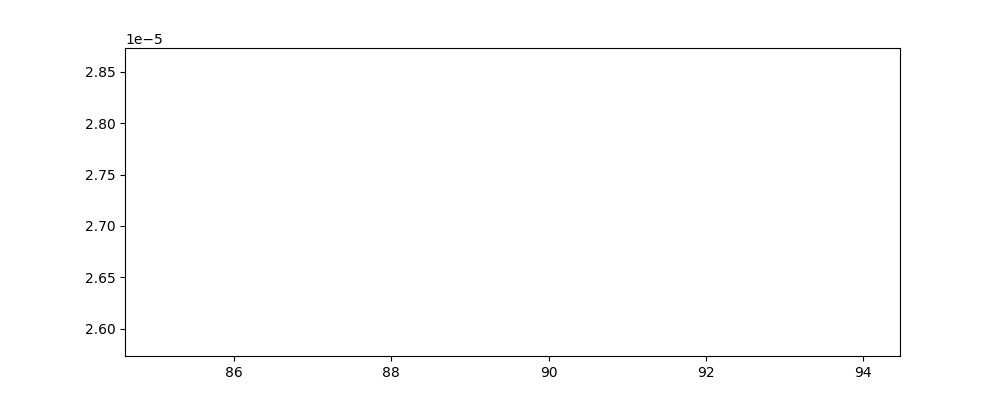

In [102]:
inc_value = 89.54 # np.arange(80, 100, 0.01)

inc_input = 87.35
sigma = 0.5 

pdf_out = double_pdf(inc_input, sigma, inc_value)
print(pdf_out)
plt.figure(figsize=(10, 4))
plt.plot(inc_value, pdf_out)
plt.show()
